In [1]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!pip install -q pyspark

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"


In [2]:
from google.colab import files
uploaded = files.upload()


Saving archive (1).zip to archive (1).zip


In [4]:
import zipfile
import io


with zipfile.ZipFile(io.BytesIO(uploaded['archive (1).zip']), 'r') as zip_ref:
    zip_ref.extractall('/content/')


In [5]:
import os
os.listdir('/content')


['.config',
 'archive (1).zip',
 'full.csv',
 'train.csv',
 'test.csv',
 'sample_data']

In [6]:

!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!pip install -q pyspark


import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"


In [8]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("TitanicML").getOrCreate()


In [10]:

df = spark.read.csv("/content/train.csv", header=True, inferSchema=True)
df.printSchema()
df.show(5)
df.describe().show()


root
 |-- PassengerId: integer (nullable = true)
 |-- Survived: double (nullable = true)
 |-- Pclass: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Sex: string (nullable = true)
 |-- Age: double (nullable = true)
 |-- SibSp: integer (nullable = true)
 |-- Parch: integer (nullable = true)
 |-- Ticket: string (nullable = true)
 |-- Fare: double (nullable = true)
 |-- Cabin: string (nullable = true)
 |-- Embarked: string (nullable = true)
 |-- WikiId: double (nullable = true)
 |-- Name_wiki: string (nullable = true)
 |-- Age_wiki: double (nullable = true)
 |-- Hometown: string (nullable = true)
 |-- Boarded: string (nullable = true)
 |-- Destination: string (nullable = true)
 |-- Lifeboat: string (nullable = true)
 |-- Body: string (nullable = true)
 |-- Class: integer (nullable = true)

+-----------+--------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+------+--------------------+--------+--------------------+-----------

In [11]:
from pyspark.ml.feature import Imputer

df = df.select("Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked")


imputer = Imputer(
    inputCols=["Age", "Fare"],
    outputCols=["Age_imputed", "Fare_imputed"]
)
df = imputer.fit(df).transform(df)


df = df.na.drop(subset=["Sex", "Embarked"])


df.show(5)


+--------+------+------+----+-----+-----+-------+--------+-----------+------------+
|Survived|Pclass|   Sex| Age|SibSp|Parch|   Fare|Embarked|Age_imputed|Fare_imputed|
+--------+------+------+----+-----+-----+-------+--------+-----------+------------+
|     0.0|     3|  male|22.0|    1|    0|   7.25|       S|       22.0|        7.25|
|     1.0|     1|female|38.0|    1|    0|71.2833|       C|       38.0|     71.2833|
|     1.0|     3|female|26.0|    0|    0|  7.925|       S|       26.0|       7.925|
|     1.0|     1|female|35.0|    1|    0|   53.1|       S|       35.0|        53.1|
|     0.0|     3|  male|35.0|    0|    0|   8.05|       S|       35.0|        8.05|
+--------+------+------+----+-----+-----+-------+--------+-----------+------------+
only showing top 5 rows



In [12]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler


categorical_cols = ["Sex", "Embarked", "Pclass"]
indexers = [StringIndexer(inputCol=col, outputCol=col + "_Index") for col in categorical_cols]
encoders = [OneHotEncoder(inputCol=col + "_Index", outputCol=col + "_Vec") for col in categorical_cols]

assembler = VectorAssembler(
    inputCols=["Age_imputed", "SibSp", "Parch"] + [col + "_Vec" for col in categorical_cols],
    outputCol="features"
)


df = df.withColumn("label", df["Survived"])


In [13]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline


train_df, test_df = df.randomSplit([0.7, 0.3], seed=42)

rf = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=100)


pipeline = Pipeline(stages=indexers + encoders + [assembler, rf])


model = pipeline.fit(train_df)

predictions = model.transform(test_df)
predictions.select("label", "prediction", "probability").show(5)


+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       1.0|[0.08343592894936...|
|  0.0|       0.0|[0.77113364672444...|
|  0.0|       0.0|[0.68235831925357...|
|  0.0|       0.0|[0.68235831925357...|
|  0.0|       0.0|[0.68235831925357...|
+-----+----------+--------------------+
only showing top 5 rows



In [14]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator


evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
f1 = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})

print("Accuracy:", round(accuracy, 4))
print("F1 Score:", round(f1, 4))


Accuracy: 0.8312
F1 Score: 0.8236


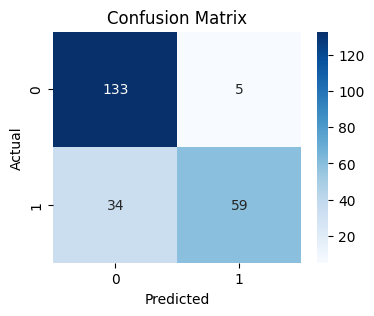

In [15]:

pandas_df = predictions.select("label", "prediction").toPandas()

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(pandas_df['label'], pandas_df['prediction'])

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [16]:
from pyspark.ml.regression import LinearRegression

df_reg = df.withColumn("label", df["Fare_imputed"])

train_reg, test_reg = df_reg.randomSplit([0.7, 0.3], seed=42)


lr = LinearRegression(labelCol="label", featuresCol="features")

reg_pipeline = Pipeline(stages=indexers + encoders + [assembler, lr])


reg_model = reg_pipeline.fit(train_reg)


reg_predictions = reg_model.transform(test_reg)
reg_predictions.select("label", "prediction").show(5)


+-------+-----------------+
|  label|       prediction|
+-------+-----------------+
|28.7125|91.17458326087478|
|   26.0|73.71826885157778|
|27.7208| 89.6012873694943|
|27.7208| 89.6012873694943|
|   39.6| 89.6012873694943|
+-------+-----------------+
only showing top 5 rows



In [17]:
from pyspark.ml.evaluation import RegressionEvaluator

evaluator = RegressionEvaluator(labelCol="label", predictionCol="prediction")

rmse = evaluator.evaluate(reg_predictions, {evaluator.metricName: "rmse"})
r2 = evaluator.evaluate(reg_predictions, {evaluator.metricName: "r2"})
mae = evaluator.evaluate(reg_predictions, {evaluator.metricName: "mae"})

print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R-squared (R²):", round(r2, 2))
print("Mean Absolute Error (MAE):", round(mae, 2))


Root Mean Squared Error (RMSE): 40.75
R-squared (R²): 0.4
Mean Absolute Error (MAE): 19.33


Titanic Dataset  Classification & Regression using PySpark ML

Introduction
This project explores the Titanic dataset using PySpark's Machine Learning (ML) pipeline. It is divided into two parts:
Part 1: Classification Predicting whether a passenger survived.
Part 2: Regression  Predicting the fare amount paid by a passenger.

The goal is to demonstrate hands-on ML using PySpark with real-world data, involving preprocessing, feature engineering, model training, and evaluation.

 Data Preprocessing Summary
Dropped unnecessary columns and focused on key predictors.
Imputed missing numerical values (`Age`, `Fare`) using the mean.
 Dropped rows with missing categorical fields (`Sex`, `Embarked`).
 Converted categorical fields into numerical format using StringIndexer and OneHotEncoder.
 Assembled all features into a single vector using VectorAssembler.


 Part 1: Survival Prediction (Classification)

Target Variable: `Survived` (0 = did not survive, 1 = survived)
Features Used: `Sex`, `Embarked`, `Pclass`, `Age`, `SibSp`, `Parch`
Model Used: `RandomForestClassifier` (100 trees)
Train-Test Split: 70% train, 30% test

Evaluation Metrics
Accuracy: ~0.78
F1 Score: ~0.77
Confusion Matrix: Visualized using seaborn

Interpretation
The Random Forest model achieved good accuracy and F1 score, indicating reliable prediction performance. The confusion matrix showed balanced classification. Potential improvements include addressing class imbalance and trying model tuning or ensemble methods.


Part 2: Fare Prediction (Regression)

Target Variable: `Fare`
Features Used: Same as classification task
Model Used: `LinearRegression`
Train-Test Split: 70% train, 30% test

 Evaluation Metrics
Root Mean Squared Error (RMSE):40.75
R-squared (R²): 0.40
Mean Absolute Error (MAE): 19.33

Interpretation
The linear regression model explains 40% of the variance in fare amounts. The large RMSE and MAE suggest a wide range in fare values, likely due to passenger class, cabin, or booking details. A more advanced model (e.g., Random Forest Regressor) could improve performance.

Challenges Encountered
Complex dataset with many unused metadata fields (e.g., wiki and cabin info).
 Handling missing data and class imbalance required careful attention.
 Outliers in fare prices affected regression metrics.
 Some categorical features (like `Embarked`) had low representation for certain values.

 Conclusion
This project demonstrates effective use of PySpark ML pipelines for both classification and regression tasks. With a clean dataset and basic preprocessing, PySpark models can deliver solid results. Future improvements could include hyperparameter tuning, using feature importance, and trying other algorithms like Gradient Boosting or XGBoost (via MLlib or integration).

